# Hey Score · Pipeline Maestro
**Datathon Hey Banco 2026 · DSC x Hey 2026**

Este notebook construye el `master_df` final con un registro por `user_id` y todas las features necesarias para el Hey Score y el clustering.

## Flujo
1. Setup (Drive + librerías)
2. Carga eficiente de los 4 datasets
3. Features de cliente (1 fila por user)
4. Features de producto (agregadas por user)
5. Features de transacciones (agregadas por user — celda más pesada)
6. Features conversacionales (NLP ligero)
7. Merge final → `master_df`
8. Hey Score (5 dimensiones)
9. K-Means clustering
10. Persistencia a Drive

**Owner:** Tech Lead (I1)  
**No lo corras en paralelo con otros notebooks pesados — Colab free tiene 12GB RAM y vamos a usar ~6-8GB.**

## 1. Setup

In [ ]:
# Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Configura aquí la ruta base del proyecto en tu Drive
# Asegúrate de que la carpeta 'data/' contenga los 4 CSVs originales
import os

BASE_PATH = '/content/drive/MyDrive/hey_datathon'
DATA_PATH = f'{BASE_PATH}/data'
OUTPUT_PATH = f'{BASE_PATH}/outputs'
FIGURES_PATH = f'{BASE_PATH}/figures'

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

# Verifica que los archivos existan
expected_files = ['hey_clientes.csv', 'hey_productos.csv', 'hey_transacciones.csv', 'dataset_50k_anonymized.csv']
for f in expected_files:
    path = f'{DATA_PATH}/{f}'
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f'✓ {f} ({size_mb:.1f} MB)')
    else:
        print(f'✗ FALTA: {f}')

✓ hey_clientes.csv (2.0 MB)
✓ hey_productos.csv (3.5 MB)
✓ hey_transacciones.csv (141.5 MB)
✓ dataset_50k_anonymized.csv (28.7 MB)


In [ ]:
# Imports
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Helper para monitorear memoria — útil para que el equipo vea qué tan pesado va el pipeline
import psutil
def mem_check(label=''):
    mem = psutil.virtual_memory()
    used_gb = mem.used / 1024**3
    avail_gb = mem.available / 1024**3
    print(f'[MEM] {label}: usado={used_gb:.2f}GB · disponible={avail_gb:.2f}GB')

mem_check('Inicial')

[MEM] Inicial: usado=0.98GB · disponible=11.42GB


## 2. Carga eficiente

**Truco clave:** los `dtype` se especifican desde `read_csv` para reducir RAM en 60-70%. Sin esto, las 802k transacciones consumen ~600MB; con esto, ~200MB.

In [ ]:
# --- Clientes ---
clientes_dtypes = {
    'user_id': 'string',
    'edad': 'int16',
    'sexo': 'category',
    'estado': 'category',
    'ciudad': 'category',
    'nivel_educativo': 'category',
    'ocupacion': 'category',
    'ingreso_mensual_mxn': 'int32',
    'antiguedad_dias': 'int16',
    'es_hey_pro': 'bool',
    'nomina_domiciliada': 'bool',
    'canal_apertura': 'category',
    'score_buro': 'int16',
    'dias_desde_ultimo_login': 'int16',
    'preferencia_canal': 'category',
    'satisfaccion_1_10': 'float32',
    'recibe_remesas': 'bool',
    'usa_hey_shop': 'bool',
    'idioma_preferido': 'category',
    'tiene_seguro': 'bool',
    'num_productos_activos': 'int8',
    'patron_uso_atipico': 'bool',
}

df_clientes = pd.read_csv(f'{DATA_PATH}/hey_clientes.csv', dtype=clientes_dtypes)
print(f'Clientes: {len(df_clientes):,} filas')
df_clientes.head(2)

Clientes: 15,025 filas


,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,527,1,app_android,10.0,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,714,3,app_android,8.0,False,True,es_MX,True,2,False


In [ ]:
# --- Productos ---
productos_dtypes = {
    'producto_id': 'string',
    'user_id': 'string',
    'tipo_producto': 'category',
    'estatus': 'category',
    'limite_credito': 'float32',
    'saldo_actual': 'float32',
    'utilizacion_pct': 'float32',
    'tasa_interes_anual': 'float32',
    'plazo_meses': 'float32',  # float porque tiene NaNs
    'monto_mensualidad': 'float32',
    'es_dato_sintetico': 'bool',
}

df_productos = pd.read_csv(
    f'{DATA_PATH}/hey_productos.csv',
    dtype=productos_dtypes,
    parse_dates=['fecha_apertura', 'fecha_ultimo_movimiento'],
)
print(f'Productos: {len(df_productos):,} filas')
df_productos.head(2)

Productos: 38,909 filas


,producto_id,user_id,tipo_producto,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
0,PRD-00000001,USR-00001,cuenta_debito,2023-06-26,activo,NaN,80954.601562,NaN,NaN,NaN,NaN,2025-11-27,True
1,PRD-00000002,USR-00001,tarjeta_credito_hey,2022-10-16,activo,144000.0,88790.398438,0.6166,35.709999,NaN,NaN,2025-09-17,True


In [ ]:
# --- Transacciones --- (la pesada: 802k filas)
txn_dtypes = {
    'transaccion_id': 'string',
    'user_id': 'string',
    'producto_id': 'string',
    'tipo_operacion': 'category',
    'canal': 'category',
    'monto': 'float32',
    'comercio_nombre': 'string',
    'categoria_mcc': 'category',
    'ciudad_transaccion': 'category',
    'estatus': 'category',
    'motivo_no_procesada': 'category',
    'intento_numero': 'int8',
    'meses_diferidos': 'float32',  # NaNs
    'cashback_generado': 'float32',
    'hora_del_dia': 'int8',
    'dia_semana': 'category',
    'es_internacional': 'bool',
    'dispositivo': 'category',
    'patron_uso_atipico': 'bool',
    'es_dato_sintetico': 'bool',
}

# Solo cargamos las columnas que vamos a usar — descartar 'descripcion_libre' ahorra ~80MB
use_cols = [c for c in txn_dtypes.keys()] + ['fecha_hora']

df_txn = pd.read_csv(
    f'{DATA_PATH}/hey_transacciones.csv',
    dtype=txn_dtypes,
    usecols=use_cols,
    parse_dates=['fecha_hora'],
)
print(f'Transacciones: {len(df_txn):,} filas')
mem_check('Tras cargar transacciones')
df_txn.head(2)

Transacciones: 802,384 filas
[MEM] Tras cargar transacciones: usado=1.17GB · disponible=11.22GB


,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,motivo_no_procesada,intento_numero,meses_diferidos,cashback_generado,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.880001,DivertidoPark,entretenimiento,"Nueva York, NY",...,NaN,1,NaN,0.34,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.000000,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,NaN,1,NaN,NaN,0,Friday,False,app_ios,False,True


In [ ]:
# --- Conversaciones ---
conv_dtypes = {
    'input': 'string',
    'output': 'string',
    'conv_id': 'string',
    'user_id': 'string',
    'channel_source': 'int8',
}

df_conv = pd.read_csv(
    f'{DATA_PATH}/dataset_50k_anonymized.csv',
    dtype=conv_dtypes,
    parse_dates=['date'],
)
print(f'Conversaciones: {len(df_conv):,} filas')
mem_check('Todos los datasets cargados')
df_conv.head(2)

Conversaciones: 49,981 filas
[MEM] Todos los datasets cargados: usado=1.22GB · disponible=11.17GB


,input,output,date,conv_id,user_id,channel_source
0,"Me enteré de una promo ""Supercashback Pagos Gu...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crédito Hey Negocios es diferent...,Claro! La Tarjeta de Crédito Hey Negocios es d...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1


## 3. Features de cliente

Ya viene un registro por usuario. Solo derivamos features extra y dejamos los importantes.

In [ ]:
# Features derivadas a nivel cliente
df_user_static = df_clientes.copy()

# Buckets de antigüedad (años)
df_user_static['antiguedad_anios'] = (df_user_static['antiguedad_dias'] / 365.25).round(1)

# Engagement bruto: invertir días desde último login (más reciente = mejor)
df_user_static['login_recency_score'] = 1 - (df_user_static['dias_desde_ultimo_login'] / 180).clip(0, 1)

# Flag de cliente joven (<25) — útil para perfilado
df_user_static['es_joven'] = df_user_static['edad'] < 25

# Renombrar 'sexo' a 'genero' para alinear con el diccionario oficial (opcional)
df_user_static = df_user_static.rename(columns={'sexo': 'genero'})

print(f'df_user_static: {df_user_static.shape}')
df_user_static.head(2)

df_user_static: (15025, 25)


,user_id,edad,genero,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico,antiguedad_anios,login_recency_score,es_joven
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,10.0,False,True,es_MX,False,2,False,4.3,0.994444,True
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,8.0,False,True,es_MX,True,2,False,3.9,0.983333,True


## 4. Features de producto

Agregamos por `user_id`: cuántos productos de cada tipo, utilización promedio, deuda total, inversión total.

In [ ]:
# Solo productos activos para señales financieras vivas
df_prod_activos = df_productos[df_productos['estatus'] == 'activo'].copy()

# Flags por tipo de producto — pivote que cuenta cuántos de cada tipo tiene cada user
tipo_counts = (
    df_prod_activos
    .groupby(['user_id', 'tipo_producto'], observed=True)
    .size()
    .unstack(fill_value=0)
    .add_prefix('n_')
)

# Métricas crediticias: utilización promedio, deuda total, límite total
creditos = df_prod_activos[df_prod_activos['utilizacion_pct'].notna()].copy()
metricas_credito = creditos.groupby('user_id').agg(
    utilizacion_promedio=('utilizacion_pct', 'mean'),
    utilizacion_max=('utilizacion_pct', 'max'),
    deuda_total=('saldo_actual', 'sum'),
    limite_total=('limite_credito', 'sum'),
    num_productos_credito=('producto_id', 'count'),
)

# Inversión total por usuario
inversiones = df_prod_activos[df_prod_activos['tipo_producto'] == 'inversion_hey']
metricas_inversion = inversiones.groupby('user_id').agg(
    monto_invertido=('saldo_actual', 'sum'),
)

# Flags binarios derivados
tipo_counts['tiene_inversion'] = tipo_counts.get('n_inversion_hey', 0) > 0
tipo_counts['tiene_credito'] = (
    tipo_counts.get('n_tarjeta_credito_hey', 0) +
    tipo_counts.get('n_credito_personal', 0) +
    tipo_counts.get('n_credito_auto', 0) +
    tipo_counts.get('n_credito_nomina', 0) +
    tipo_counts.get('n_tarjeta_credito_garantizada', 0) +
    tipo_counts.get('n_tarjeta_credito_negocios', 0)
) > 0
tipo_counts['tiene_cuenta_negocios'] = tipo_counts.get('n_cuenta_negocios', 0) > 0

# Merge de las tres tablas de productos
df_user_prod = (
    tipo_counts
    .join(metricas_credito, how='left')
    .join(metricas_inversion, how='left')
    .reset_index()
)

# Llenar NaN con 0 (usuario sin crédito = 0 deuda, 0 utilización, etc.)
fill_zero_cols = ['utilizacion_promedio', 'utilizacion_max', 'deuda_total', 'limite_total',
                  'num_productos_credito', 'monto_invertido']
df_user_prod[fill_zero_cols] = df_user_prod[fill_zero_cols].fillna(0)

print(f'df_user_prod: {df_user_prod.shape}')
df_user_prod.head(2)

df_user_prod: (14208, 21)


,user_id,n_credito_auto,n_credito_nomina,n_credito_personal,n_cuenta_debito,n_cuenta_negocios,n_inversion_hey,n_seguro_compras,n_seguro_vida,n_tarjeta_credito_garantizada,...,n_tarjeta_credito_negocios,tiene_inversion,tiene_credito,tiene_cuenta_negocios,utilizacion_promedio,utilizacion_max,deuda_total,limite_total,num_productos_credito,monto_invertido
0,USR-00001,0,0,0,1,0,0,0,0,0,...,0,False,True,False,0.6166,0.6166,88790.398438,144000.0,1.0,0.0
1,USR-00002,0,0,0,1,0,0,0,0,0,...,0,False,True,False,0.2783,0.2783,6122.600098,22000.0,1.0,0.0


## 5. Features de transacciones (la celda pesada)

**Estrategia:** un solo `groupby('user_id')` con muchas agregaciones simultáneas. Esto es ~10x más rápido que hacer múltiples groupbys separados.

Si esta celda se queda sin RAM en tu Colab, baja a `df_txn = df_txn.sample(frac=0.5)` arriba de esta celda — sigue siendo representativo para el clustering.

In [ ]:
mem_check('Antes de groupby de txn')

# Flags pre-calculados para que el groupby sea limpio
df_txn['es_compra'] = df_txn['tipo_operacion'] == 'compra'
df_txn['es_pago_credito'] = df_txn['tipo_operacion'] == 'pago_credito'
df_txn['es_no_procesada'] = df_txn['estatus'] == 'no_procesada'
df_txn['es_disputa'] = df_txn['estatus'] == 'en_disputa'
df_txn['es_completada'] = df_txn['estatus'] == 'completada'
df_txn['es_oxxo'] = df_txn['canal'] == 'oxxo'
df_txn['es_codi'] = df_txn['canal'] == 'codi'
df_txn['es_app'] = df_txn['canal'].isin(['app_ios', 'app_android', 'app_huawei'])

# Una sola pasada de groupby — todas las agregaciones de golpe
agg_dict = {
    'monto': ['sum', 'mean', 'std', 'count'],
    'es_compra': 'sum',
    'es_pago_credito': 'sum',
    'es_no_procesada': 'sum',
    'es_disputa': 'sum',
    'es_completada': 'sum',
    'es_oxxo': 'sum',
    'es_codi': 'sum',
    'es_app': 'sum',
    'es_internacional': 'sum',
    'patron_uso_atipico': 'sum',
    'cashback_generado': 'sum',
    'fecha_hora': ['min', 'max'],
}

df_user_txn = df_txn.groupby('user_id', observed=True).agg(agg_dict)

# Aplanar el MultiIndex de columnas
df_user_txn.columns = ['_'.join(col).strip('_') for col in df_user_txn.columns.values]
df_user_txn = df_user_txn.reset_index()

# Renombrar para legibilidad
df_user_txn = df_user_txn.rename(columns={
    'monto_sum': 'gasto_total',
    'monto_mean': 'gasto_promedio',
    'monto_std': 'variabilidad_gasto',
    'monto_count': 'num_txn_total',
    'es_compra_sum': 'num_compras',
    'es_pago_credito_sum': 'num_pagos_credito',
    'es_no_procesada_sum': 'num_rechazos',
    'es_disputa_sum': 'num_disputas',
    'es_completada_sum': 'num_completadas',
    'es_oxxo_sum': 'num_oxxo',
    'es_codi_sum': 'num_codi',
    'es_app_sum': 'num_txn_app',
    'es_internacional_sum': 'num_internacional',
    'patron_uso_atipico_sum': 'num_atipicos',
    'cashback_generado_sum': 'cashback_total',
    'fecha_hora_min': 'primera_txn',
    'fecha_hora_max': 'ultima_txn',
})

# Tasa de rechazo — feature clave para Solidez crediticia
df_user_txn['tasa_rechazo'] = (df_user_txn['num_rechazos'] / df_user_txn['num_txn_total']).fillna(0)

# Variabilidad de gasto: NaN cuando hay 1 sola txn → llenamos con 0
df_user_txn['variabilidad_gasto'] = df_user_txn['variabilidad_gasto'].fillna(0)

mem_check('Tras groupby de txn')
print(f'df_user_txn: {df_user_txn.shape}')
df_user_txn.head(2)

[MEM] Antes de groupby de txn: usado=1.22GB · disponible=11.17GB
[MEM] Tras groupby de txn: usado=1.22GB · disponible=11.17GB
df_user_txn: (15025, 19)


,user_id,gasto_total,gasto_promedio,variabilidad_gasto,num_txn_total,num_compras,num_pagos_credito,num_rechazos,num_disputas,num_completadas,num_oxxo,num_codi,num_txn_app,num_internacional,num_atipicos,cashback_total,primera_txn,ultima_txn,tasa_rechazo
0,USR-00001,119570.585938,2135.188965,5423.051271,56,31,2,3,0,53,2,2,45,2,0,122.330002,2025-01-15 14:17:42,2025-11-22 09:39:34,0.053571
1,USR-00002,212722.671875,2874.630615,6102.422197,74,43,3,1,1,71,0,1,52,1,0,147.080002,2025-01-16 21:06:25,2025-11-27 11:36:49,0.013514


In [ ]:
# Categorías únicas por usuario — feature de diversidad de gasto
categorias_unicas = (
    df_txn[df_txn['categoria_mcc'].notna()]
    .groupby('user_id', observed=True)['categoria_mcc']
    .nunique()
    .reset_index()
    .rename(columns={'categoria_mcc': 'categorias_unicas'})
)

# Categoría dominante (top 1 por gasto) — para storytelling en demo
categoria_top = (
    df_txn[df_txn['es_compra']]
    .groupby(['user_id', 'categoria_mcc'], observed=True)['monto']
    .sum()
    .reset_index()
    .sort_values(['user_id', 'monto'], ascending=[True, False])
    .drop_duplicates('user_id', keep='first')
    [['user_id', 'categoria_mcc']]
    .rename(columns={'categoria_mcc': 'categoria_dominante'})
)

df_user_txn = df_user_txn.merge(categorias_unicas, on='user_id', how='left')
df_user_txn = df_user_txn.merge(categoria_top, on='user_id', how='left')
df_user_txn['categorias_unicas'] = df_user_txn['categorias_unicas'].fillna(0).astype('int8')

# Liberar memoria del df de transacciones original — ya no lo necesitamos
del df_txn
import gc
gc.collect()
mem_check('Tras liberar df_txn')

print(f'df_user_txn final: {df_user_txn.shape}')
df_user_txn.head(2)

[MEM] Tras liberar df_txn: usado=1.21GB · disponible=11.18GB
df_user_txn final: (15025, 21)


,user_id,gasto_total,gasto_promedio,variabilidad_gasto,num_txn_total,num_compras,num_pagos_credito,num_rechazos,num_disputas,num_completadas,...,num_codi,num_txn_app,num_internacional,num_atipicos,cashback_total,primera_txn,ultima_txn,tasa_rechazo,categorias_unicas,categoria_dominante
0,USR-00001,119570.585938,2135.188965,5423.051271,56,31,2,3,0,53,...,2,45,2,0,122.330002,2025-01-15 14:17:42,2025-11-22 09:39:34,0.053571,7,restaurante
1,USR-00002,212722.671875,2874.630615,6102.422197,74,43,3,1,1,71,...,1,52,1,0,147.080002,2025-01-16 21:06:25,2025-11-27 11:36:49,0.013514,7,restaurante


## 6. Features conversacionales

**Decisión:** léxico simple en lugar de pysentimiento. Razones documentadas en el plan: ahorra 4-6h, no necesita GPU, suficiente para perfilar segmentos.

Si I3 (Storytelling) o I4 (Pitch) preguntan por qué no usaste un modelo grande, la respuesta es: **"priorizamos pipeline robusto sobre métrica de NLP individual; el sentimiento entra como una de 5 dimensiones, no como predictor único"**.

In [ ]:
# Léxico simple en español. Expandible — el equipo puede agregar términos.
PALABRAS_NEGATIVAS = {
    'no funciona', 'rechazado', 'rechazo', 'no puedo', 'error', 'problema',
    'no me deja', 'mal', 'frustrante', 'urgente', 'queja', 'reclamo',
    'cobro indebido', 'no autorizado', 'desconozco', 'fraude', 'robo',
    'enojado', 'molesto', 'pésimo', 'pesimo', 'horrible', 'terrible',
    'cancelar', 'cancelacion', 'cancelación', 'no sirve', 'falla',
}

PALABRAS_POSITIVAS = {
    'gracias', 'excelente', 'perfecto', 'genial', 'rápido', 'rapido',
    'fácil', 'facil', 'buen servicio', 'me encanta', 'satisfecho',
    'recomendaría', 'recomendaria', 'súper', 'super',
}

# Categorización por keywords — temas
TEMAS = {
    'credito': ['crédito', 'credito', 'tarjeta', 'préstamo', 'prestamo', 'limite', 'límite'],
    'cobros': ['cargo', 'cobro', 'no reconozco', 'desconozco', 'no autorizado', 'fraude', 'duplicado'],
    'liquidez': ['saldo', 'transferencia', 'spei', 'depósito', 'deposito', 'retiro'],
    'soporte': ['app', 'aplicación', 'aplicacion', 'login', 'contraseña', 'password', 'no puedo entrar'],
    'productos': ['inversión', 'inversion', 'seguro', 'hey pro', 'cashback', 'nómina', 'nomina'],
}

def score_sentimiento(texto):
    """Devuelve un float entre -1 (muy negativo) y +1 (muy positivo)."""
    if not isinstance(texto, str):
        return 0.0
    t = texto.lower()
    neg = sum(1 for p in PALABRAS_NEGATIVAS if p in t)
    pos = sum(1 for p in PALABRAS_POSITIVAS if p in t)
    if neg + pos == 0:
        return 0.0
    return (pos - neg) / (pos + neg)

def detectar_tema(texto):
    """Devuelve el tema dominante o 'otro'."""
    if not isinstance(texto, str):
        return 'otro'
    t = texto.lower()
    scores = {tema: sum(1 for kw in kws if kw in t) for tema, kws in TEMAS.items()}
    if max(scores.values()) == 0:
        return 'otro'
    return max(scores, key=scores.get)

In [ ]:
# Aplicar a todas las conversaciones — esto toma ~30-60s sobre 50k filas
df_conv['sentimiento'] = df_conv['input'].apply(score_sentimiento)
df_conv['tema'] = df_conv['input'].apply(detectar_tema)

print(df_conv['tema'].value_counts())
print(f"\nSentimiento promedio global: {df_conv['sentimiento'].mean():.3f}")
df_conv[['user_id', 'tema', 'sentimiento']].head(5)

tema
otro         29767
credito      13273
liquidez      2813
cobros        1554
soporte       1467
productos     1107
Name: count, dtype: int64

Sentimiento promedio global: -0.045


,user_id,tema,sentimiento
0,USR-09092,productos,1.0
1,USR-09092,credito,-1.0
2,USR-09092,otro,1.0
3,USR-09344,otro,0.0
4,USR-09344,otro,0.0


In [ ]:
# Agregaciones por usuario
# 1. Counts y sentimiento promedio
conv_agg = df_conv.groupby('user_id').agg(
    num_interacciones=('input', 'count'),
    num_conversaciones=('conv_id', 'nunique'),
    sentimiento_promedio=('sentimiento', 'mean'),
    sentimiento_min=('sentimiento', 'min'),
).reset_index()

# 2. Tema dominante por usuario
tema_dominante = (
    df_conv.groupby(['user_id', 'tema'])
    .size()
    .reset_index(name='count')
    .sort_values(['user_id', 'count'], ascending=[True, False])
    .drop_duplicates('user_id', keep='first')
    [['user_id', 'tema']]
    .rename(columns={'tema': 'tema_dominante'})
)

# 3. Fricción de atención: turnos promedio por conversación
friccion = (
    df_conv.groupby('conv_id')
    .agg(turnos=('input', 'count'), user_id=('user_id', 'first'))
    .groupby('user_id')['turnos']
    .mean()
    .reset_index()
    .rename(columns={'turnos': 'friccion_atencion'})
)

df_user_conv = (
    conv_agg
    .merge(tema_dominante, on='user_id', how='left')
    .merge(friccion, on='user_id', how='left')
)

print(f'df_user_conv: {df_user_conv.shape}')
df_user_conv.head(2)

df_user_conv: (15025, 7)


,user_id,num_interacciones,num_conversaciones,sentimiento_promedio,sentimiento_min,tema_dominante,friccion_atencion
0,USR-00001,3,1,0.0,0.0,credito,3.0
1,USR-00002,3,1,0.0,0.0,otro,3.0


## 7. Merge final → master_df

In [ ]:
# Left join sobre clientes — todos los usuarios deben aparecer aunque no tengan transacciones o conversaciones
master_df = (
    df_user_static
    .merge(df_user_prod, on='user_id', how='left')
    .merge(df_user_txn, on='user_id', how='left')
    .merge(df_user_conv, on='user_id', how='left')
)

# Llenar NaN para usuarios sin transacciones/conversaciones
numeric_fill_zero = [
    'gasto_total', 'gasto_promedio', 'variabilidad_gasto', 'num_txn_total',
    'num_compras', 'num_pagos_credito', 'num_rechazos', 'num_disputas',
    'num_completadas', 'num_oxxo', 'num_codi', 'num_txn_app',
    'num_internacional', 'num_atipicos', 'cashback_total', 'tasa_rechazo',
    'categorias_unicas', 'num_interacciones', 'num_conversaciones',
    'sentimiento_promedio', 'sentimiento_min', 'friccion_atencion',
]
for col in numeric_fill_zero:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0)

master_df['categoria_dominante'] = master_df['categoria_dominante'].astype('object').fillna('sin_actividad')
master_df['tema_dominante'] = master_df['tema_dominante'].astype('object').fillna('sin_interaccion')

print(f'master_df: {master_df.shape}')
print(f'\nColumnas:')
for c in master_df.columns:
    print(f'  {c}')
print(master_df.head(3))


master_df: (15025, 71)

Columnas:
  user_id
  edad
  genero
  estado
  ciudad
  nivel_educativo
  ocupacion
  ingreso_mensual_mxn
  antiguedad_dias
  es_hey_pro
  nomina_domiciliada
  canal_apertura
  score_buro
  dias_desde_ultimo_login
  preferencia_canal
  satisfaccion_1_10
  recibe_remesas
  usa_hey_shop
  idioma_preferido
  tiene_seguro
  num_productos_activos
  patron_uso_atipico
  antiguedad_anios
  login_recency_score
  es_joven
  n_credito_auto
  n_credito_nomina
  n_credito_personal
  n_cuenta_debito
  n_cuenta_negocios
  n_inversion_hey
  n_seguro_compras
  n_seguro_vida
  n_tarjeta_credito_garantizada
  n_tarjeta_credito_hey
  n_tarjeta_credito_negocios
  tiene_inversion
  tiene_credito
  tiene_cuenta_negocios
  utilizacion_promedio
  utilizacion_max
  deuda_total
  limite_total
  num_productos_credito
  monto_invertido
  gasto_total
  gasto_promedio
  variabilidad_gasto
  num_txn_total
  num_compras
  num_pagos_credito
  num_rechazos
  num_disputas
  num_completadas
  num_

## 8. Hey Score (5 dimensiones, 0-100 total)

**Estrategia clave:** normalización por **percentil dentro del dataset**, no por valores absolutos. Esto garantiza distribución balanceada del score final (no todos amontonados en 50-60).

In [ ]:
# NOTA: 817 usuarios existen en clientes pero no en productos (left join).
# Sus columnas de producto llegan como NaN y se rellenan con 0/False
# antes de calcular el score para evitar que rankdata falle silenciosamente.
from scipy.stats import rankdata

columnas_criticas = [
    'score_buro', 'utilizacion_promedio', 'tasa_rechazo',
    'monto_invertido', 'ingreso_mensual_mxn', 'num_pagos_credito',
    'num_compras', 'variabilidad_gasto'
]

for col in columnas_criticas:
    master_df[col] = master_df[col].fillna(0)

def percentil_score(series, invertir=False):
    s = series.copy()
    # Si todos son ceros, no intentes rankear, devuelve ceros
    if s.sum() == 0:
        return pd.Series(0.0, index=s.index)

    not_null = s.notna()
    result = pd.Series(0.0, index=s.index)
    if not_null.sum() > 1:
        ranks = rankdata(s[not_null], method='min') # 'min' ayuda con los empates en cero
        pct = (ranks - 1) / (len(ranks) - 1)
        result[not_null] = 1 - pct if invertir else pct
    return result

# Llenar NaNs antes de calcular — usuarios sin productos = 0
master_df['utilizacion_promedio'] = master_df['utilizacion_promedio'].fillna(0)
master_df['tiene_inversion']      = master_df['tiene_inversion'].fillna(False)
master_df['monto_invertido']      = master_df['monto_invertido'].fillna(0)

# === DIMENSIÓN 1: Solidez crediticia (0-20) ===
d1_buro = percentil_score(master_df['score_buro'])
d1_util = percentil_score(master_df['utilizacion_promedio'], invertir=True)
d1_rech = percentil_score(master_df['tasa_rechazo'], invertir=True)
master_df['dim_solidez'] = (d1_buro * 0.5 + d1_util * 0.3 + d1_rech * 0.2) * 20

# === DIMENSIÓN 2: Diversificación (0-20) ===
d2_nprod = percentil_score(master_df['num_productos_activos'])
d2_inv   = master_df['tiene_inversion'].astype(float)
d2_seg   = master_df['tiene_seguro'].astype(float)
master_df['dim_diversificacion'] = (d2_nprod * 0.5 + d2_inv * 0.25 + d2_seg * 0.25) * 20

# === DIMENSIÓN 3: Comportamiento de gasto (0-20) ===
ratio_pago = (master_df['num_pagos_credito'] / master_df['num_compras'].clip(lower=1)).clip(0, 1)
d3_pago = percentil_score(ratio_pago)
d3_cat  = percentil_score(master_df['categorias_unicas'])
var_pct = percentil_score(master_df['variabilidad_gasto'])
d3_var  = 1 - 2 * abs(var_pct - 0.5)
master_df['dim_gasto'] = (d3_pago * 0.4 + d3_cat * 0.3 + d3_var * 0.3) * 20

# === DIMENSIÓN 4: Engagement bancario (0-20) ===
d4_nomina = master_df['nomina_domiciliada'].astype(float)
d4_login  = master_df['login_recency_score']
d4_shop   = master_df['usa_hey_shop'].astype(float)
d4_pro    = master_df['es_hey_pro'].astype(float)
master_df['dim_engagement'] = (d4_nomina * 0.3 + d4_login * 0.3 + d4_shop * 0.2 + d4_pro * 0.2) * 20

# === DIMENSIÓN 5: Protección financiera (0-20) ===
d5_seg   = master_df['tiene_seguro'].astype(float)
d5_inv   = master_df['tiene_inversion'].astype(float)
ingreso_anual   = master_df['ingreso_mensual_mxn'] * 12
ratio_inv_ingreso = (master_df['monto_invertido'] / ingreso_anual.clip(lower=1)).clip(0, 1)
d5_ratio = percentil_score(ratio_inv_ingreso)
master_df['dim_proteccion'] = (d5_seg * 0.35 + d5_inv * 0.25 + d5_ratio * 0.4) * 20

# === HEY SCORE TOTAL (0-100) ===
master_df['hey_score'] = (
    master_df['dim_solidez'] +
    master_df['dim_diversificacion'] +
    master_df['dim_gasto'] +
    master_df['dim_engagement'] +
    master_df['dim_proteccion']
).round(1)

print(f"Hey Score — distribución:")
print(master_df['hey_score'].describe())

Hey Score — distribución:
count    15025.000000
mean        42.034369
std         16.312621
min          6.900000
25%         29.900000
50%         38.400000
75%         54.400000
max         88.700000
Name: hey_score, dtype: float64


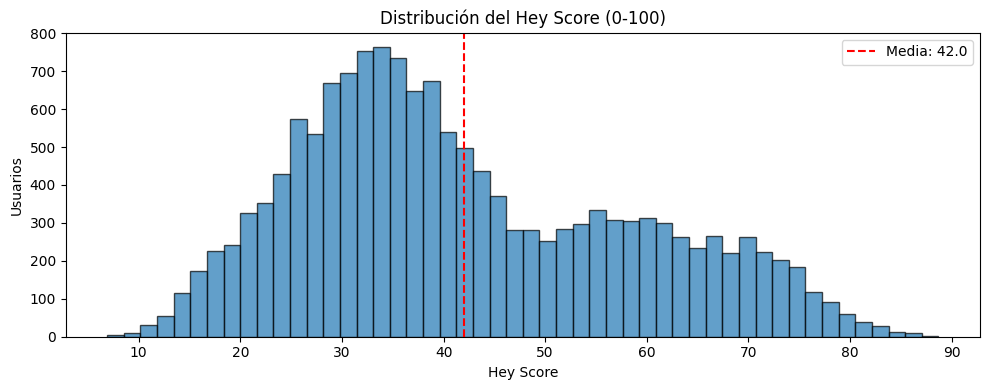

In [ ]:
# Histograma rápido del score — si se ve bimodal o degenerado, parar y revisar
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(master_df['hey_score'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(master_df['hey_score'].mean(), color='red', linestyle='--', label=f"Media: {master_df['hey_score'].mean():.1f}")
ax.set_xlabel('Hey Score')
ax.set_ylabel('Usuarios')
ax.set_title('Distribución del Hey Score (0-100)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/hey_score_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. K-Means clustering

**No fijo K=5 a priori.** Pruebo K=3 a K=8 y elijo por silhouette.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Features para clustering — mezcla financiera + conversacional + demográfica
cluster_features = [
    'edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro',
    'num_productos_activos', 'utilizacion_promedio', 'deuda_total', 'monto_invertido',
    'gasto_total', 'num_txn_total', 'tasa_rechazo', 'categorias_unicas',
    'num_interacciones', 'sentimiento_promedio', 'friccion_atencion',
    'hey_score',
]

X = master_df[cluster_features].fillna(0).values

# Log-transform a las features muy sesgadas (ingresos, gasto, deuda)
log_cols_idx = [cluster_features.index(c) for c in ['ingreso_mensual_mxn', 'deuda_total', 'monto_invertido', 'gasto_total']]
for idx in log_cols_idx:
    X[:, idx] = np.log1p(X[:, idx])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Probar varios K
results = []
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    db = davies_bouldin_score(X_scaled, labels)
    results.append({'k': k, 'silhouette': sil, 'davies_bouldin': db, 'inertia': km.inertia_})
    print(f'K={k} · silhouette={sil:.3f} · DB={db:.3f}')

results_df = pd.DataFrame(results)
results_df

K=3 · silhouette=0.189 · DB=1.820
K=4 · silhouette=0.189 · DB=1.813
K=5 · silhouette=0.183 · DB=1.797
K=6 · silhouette=0.167 · DB=1.931
K=7 · silhouette=0.165 · DB=1.830
K=8 · silhouette=0.165 · DB=1.811


,k,silhouette,davies_bouldin,inertia
0,3,0.188971,1.820209,164413.318032
1,4,0.188696,1.813355,150260.058527
2,5,0.183051,1.796603,139678.878884
3,6,0.167329,1.930653,132215.454599
4,7,0.165495,1.829948,126111.390730
5,8,0.165277,1.811050,121162.973819


In [ ]:
# Elegir el mejor K (mejor silhouette)
#best_k = int(results_df.loc[results_df['silhouette'].idxmax(), 'k'])
best_k = 5
print(f'\n>>> K elegido: {best_k}')

# Modelo final
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
master_df['cluster_id'] = kmeans_final.fit_predict(X_scaled)

# Perfilado de clusters — medias por cluster sobre features clave
perfil = master_df.groupby('cluster_id').agg(
    n_usuarios=('user_id', 'count'),
    edad_media=('edad', 'mean'),
    ingreso_medio=('ingreso_mensual_mxn', 'mean'),
    score_buro_medio=('score_buro', 'mean'),
    hey_score_medio=('hey_score', 'mean'),
    utilizacion_media=('utilizacion_promedio', 'mean'),
    pct_hey_pro=('es_hey_pro', 'mean'),
    pct_nomina=('nomina_domiciliada', 'mean'),
    pct_inversion=('tiene_inversion', 'mean'),
    pct_seguro=('tiene_seguro', 'mean'),
    sentimiento=('sentimiento_promedio', 'mean'),
    tasa_rechazo=('tasa_rechazo', 'mean'),
).round(2)

perfil


>>> K elegido: 5


,n_usuarios,edad_media,ingreso_medio,score_buro_medio,hey_score_medio,utilizacion_media,pct_hey_pro,pct_nomina,pct_inversion,pct_seguro,sentimiento,tasa_rechazo
cluster_id,,,,,,,,,,,,
0,5276,34.96,31629.64,638.50,38.44,0.38,0.55,0.44,0.01,0.22,-0.07,0.02
1,3979,40.91,41016.21,716.18,64.32,0.16,0.69,0.36,0.99,0.47,-0.07,0.02
2,1786,40.53,19647.82,540.09,22.04,0.04,0.09,0.11,0.00,0.19,-0.07,0.03
3,1316,36.53,15338.91,453.92,28.71,0.81,0.23,0.26,0.00,0.20,-0.07,0.09
4,2668,34.13,23347.64,566.68,35.85,0.00,0.47,0.31,0.01,0.20,-0.07,0.05


In [ ]:
# Etiquetado heurístico — 5 etiquetas para K=5

def etiquetar_cluster(row):
    cid = row.name  # cluster_id es el índice del groupby
    if cid == 1:
        return '💎 Cliente consolidado'
    elif cid == 3:
        return '🚨 Usuario en riesgo'
    elif cid == 2:
        return '🌱 Recién bancarizado'
    elif cid == 4:
        return '😴 Usuario pasivo'
    else:  # cid == 0
        return '⚠️ Usuario de crédito activo'

perfil['etiqueta'] = perfil.apply(etiquetar_cluster, axis=1)
etiqueta_map = perfil['etiqueta'].to_dict()
master_df['cluster_etiqueta'] = master_df['cluster_id'].map(etiqueta_map)

print(perfil[['n_usuarios', 'hey_score_medio', 'etiqueta']])
print("\nDistribución:")
print(master_df['cluster_etiqueta'].value_counts())

            n_usuarios  hey_score_medio                      etiqueta
cluster_id                                                           
0                 5276            38.44  ⚠️ Usuario de crédito activo
1                 3979            64.32         💎 Cliente consolidado
2                 1786            22.04          🌱 Recién bancarizado
3                 1316            28.71           🚨 Usuario en riesgo
4                 2668            35.85              😴 Usuario pasivo

Distribución:
cluster_etiqueta
⚠️ Usuario de crédito activo    5276
💎 Cliente consolidado           3979
😴 Usuario pasivo                2668
🌱 Recién bancarizado            1786
🚨 Usuario en riesgo             1316
Name: count, dtype: int64


In [ ]:
import pandas as pd

# ¿Llegaron las columnas clave?
cols_check = ['user_id', 'hey_score', 'dim_solidez', 'dim_diversificacion',
              'dim_gasto', 'dim_engagement', 'dim_proteccion',
              'cluster_id', 'cluster_etiqueta', 'tema_dominante', 'sentimiento_promedio']

for col in cols_check:
    if col in master_df.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ FALTA: {col}")



✓ user_id
✓ hey_score
✓ dim_solidez
✓ dim_diversificacion
✓ dim_gasto
✓ dim_engagement
✓ dim_proteccion
✓ cluster_id
✓ cluster_etiqueta
✓ tema_dominante
✓ sentimiento_promedio


## 10. Persistencia a Drive

In [ ]:
import joblib



# Guardar artefactos para que I2 (demo) e I3 (storytelling) los consuman
master_df.to_parquet(f'{OUTPUT_PATH}/master_df.parquet', index=False)
perfil.to_csv(f'{OUTPUT_PATH}/cluster_profiles.csv')
results_df.to_csv(f'{OUTPUT_PATH}/clustering_metrics.csv', index=False)

joblib.dump(kmeans_final, f'{OUTPUT_PATH}/kmeans_model.pkl')
joblib.dump(scaler, f'{OUTPUT_PATH}/scaler.pkl')

# Score por usuario — formato simple para consumo rápido
score_per_user = master_df[[
    'user_id', 'hey_score',
    'dim_solidez', 'dim_diversificacion', 'dim_gasto', 'dim_engagement', 'dim_proteccion',
    'cluster_id', 'cluster_etiqueta',
    'tema_dominante', 'sentimiento_promedio',
]]
score_per_user.to_csv(f'{OUTPUT_PATH}/score_per_user.csv', index=False)

print('✓ Archivos guardados en Drive:')
for f in os.listdir(OUTPUT_PATH):
    size = os.path.getsize(f'{OUTPUT_PATH}/{f}') / 1024
    print(f'  {f} ({size:.1f} KB)')

print(f'\n>>> AVISA AL EQUIPO: el master_df está listo. I2 e I3 pueden empezar a consumir.')

# Checar si las dimensiones tiene valores
dims = ['dim_solidez', 'dim_diversificacion', 'dim_gasto', 'dim_engagement', 'dim_proteccion']
for d in dims:
    validos = master_df[d].notna().sum()
    print(f"{d}: {validos} validos de 15025")

print(master_df["cluster_etiqueta"].unique())


✓ Archivos guardados en Drive:
  clustering_metrics.csv (0.4 KB)
  cluster_profiles.csv (0.6 KB)
  kmeans_model.pkl (60.0 KB)
  scaler.pkl (1.0 KB)
  master_df.parquet (1730.5 KB)
  score_per_user.csv (1967.7 KB)

>>> AVISA AL EQUIPO: el master_df está listo. I2 e I3 pueden empezar a consumir.
dim_solidez: 15025 validos de 15025
dim_diversificacion: 15025 validos de 15025
dim_gasto: 15025 validos de 15025
dim_engagement: 15025 validos de 15025
dim_proteccion: 15025 validos de 15025
['🚨 Usuario en riesgo' '⚠️ Usuario de crédito activo'
 '💎 Cliente consolidado' '😴 Usuario pasivo' '🌱 Recién bancarizado']


## Pipeline completo

**Outputs disponibles en `/outputs`:**
- `master_df.parquet` — la tabla maestra completa (15k usuarios × ~60 cols)
- `score_per_user.csv` — score y cluster por usuario (consumo rápido)
- `cluster_profiles.csv` — perfil de cada segmento
- `clustering_metrics.csv` — silhouette/DB para distintos K (para el pitch)
- `kmeans_model.pkl` — modelo entrenado (para scoring de nuevos usuarios)
- `scaler.pkl` — scaler ajustado (necesario para usar el modelo)

**Siguiente paso:** dame luz verde y te genero el Notebook 2 (Demo Gradio + Havi proactivo) que I2 va a correr.